# Hazard assessment — River flooding (Kazakhstan)

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[FLOODS](https://github.com/CLIMAAX/FLOODS) GitHub repository.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| JRC CEMS-EFAS flood maps (`jeodpp.jrc.ec.europa.eu/.../CEMS-EFAS/`) — Europe-only | JRC CEMS-GLOFAS flood maps (`jeodpp.jrc.ec.europa.eu/.../CEMS-GLOFAS/`) — global | EFAS covers only Europe; GLOFAS is the JRC global equivalent using the same methodology and ~90 m resolution |
| Single continental GeoTIFF per return period | Multiple 10°×10° tiles identified via `tile_extents.geojson`, downloaded and mosaicked | GLOFAS distributes data globally as tiles; the tile index is used to identify only those covering Kazakhstan |
| `EPSG:3035` (EU Lambert Azimuthal Equal Area) | `EPSG:4326` (WGS84 geographic) | EPSG:3035 is Europe-specific and undefined outside Europe |
| NUTS3 / EU administrative regions | Kazakhstan OSM shapefile (oblasts) | EU administrative units are not applicable outside Europe |
| WRI Aqueduct Floods (future scenarios) | **Unchanged** — already a global dataset | Aqueduct is already global; scenario labels (RCP4.5/RCP8.5) are the same as in the original CLIMAAX river flood workflow |

**Available return periods in CEMS-GLOFAS:** 10, 20, 50, 75, 100, 200, 500 years.
This workflow uses: 10, 50, 100, 200, 500.

**Resolution note:** CEMS-GLOFAS is ~90 m (3 arc-seconds); Aqueduct is ~1 km
(30 arc-seconds). The Aqueduct future-scenario results are qualitative indicators
of climate change direction and are not suitable for local-scale flood depth
estimation.

## Setup — libraries

In [ ]:
import re
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box

try:
    import pooch
except ImportError:
    raise ImportError("Run:  conda install -c conda-forge pooch")

logging.getLogger("pooch").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

## Setup — region and bounding box

In [ ]:
SHAPEFILE_PATH = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
)
OBLAST_FIELD = "oblast_en"

selected_oblast = "Astana"

kaz = gpd.read_file(SHAPEFILE_PATH)

if selected_oblast is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    region_name = re.sub(r"[^a-zA-Z0-9]", "", selected_oblast)
    region_id   = selected_oblast
else:
    region_gdf  = gpd.GeoDataFrame(
        geometry=[kaz.geometry.unary_union], crs=kaz.crs
    )
    region_name = "Kazakhstan"
    region_id   = "KAZ"

coords = gpd.GeoSeries.get_coordinates(region_gdf).to_numpy()

bbox = [
    float(coords[:, 0].min()),
    float(coords[:, 1].min()),
    float(coords[:, 0].max()),
    float(coords[:, 1].max()),
]

print(f"Region     : {region_id}")
print(f"Lon range  : [{bbox[0]:.2f}, {bbox[2]:.2f}]")
print(f"Lat range  : [{bbox[1]:.2f}, {bbox[3]:.2f}]")
print(f"Bounding box: {bbox}")

Region     : Astana
Lon range  : [71.22, 71.79]
Lat range  : [50.86, 51.35]
Bounding box: [71.21797350000003, 50.85760759999994, 71.78519130000012, 51.35111010000014]


## Setup — directory structure

In [ ]:
workflow_dir        = Path(__file__).parent if "__file__" in dir() else Path(".")
general_data_folder = workflow_dir / "general_data"
glofas_tiles_folder = general_data_folder / "glofas_tiles"
results_dir         = workflow_dir / "results" / region_name
plot_dir            = results_dir / "plots"
data_dir            = results_dir / "data"
data_dir_aqueduct   = data_dir / "aqueduct_floods"

for d in [general_data_folder, glofas_tiles_folder,
          results_dir, plot_dir, data_dir, data_dir_aqueduct]:
    d.mkdir(parents=True, exist_ok=True)

print("Directory structure ready.")

Directory structure ready.


---
## Part 1 — Present-day flood hazard: CEMS-GLOFAS global flood maps

The JRC CEMS-GLOFAS dataset is the global equivalent of the CEMS-EFAS dataset
used in the original CLIMAAX workflow.  Both are produced by JRC, share the
same methodology, and use the same return period labelling.  Resolution is
~3 arc-seconds (≈90 m at Kazakhstan's latitudes).

**Tiling strategy:** GLOFAS distributes data as 10°×10° tiles named
`ID{n}_{lat}_{lon}_RP{rp}_depth.tif`.  We first download the published
`tile_extents.geojson` index to identify which tiles intersect our bounding
box, then download only those tiles and mosaic them.

**Note:** The GLOFAS FTP URL structure below was confirmed to exist; if a tile
download fails with HTTP 404, check the base URL with a browser first:
`https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard/`

### Step 1 — Download tile index and identify Kazakhstan tiles

In [ ]:
GLOFAS_BASE  = (
    "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard"
)
return_periods = [10, 50, 100, 200, 500]

tile_index_path = general_data_folder / "tile_extents.geojson"

if not tile_index_path.exists():
    pooch.retrieve(
        url=f"{GLOFAS_BASE}/tile_extents.geojson",
        known_hash=None,
        path=general_data_folder,
        fname="tile_extents.geojson",
    )
    print("Downloaded: tile_extents.geojson")
else:
    print("Cached: tile_extents.geojson")

Cached: tile_extents.geojson


In [ ]:
tiles_gdf = gpd.read_file(tile_index_path)
print(f"Total tiles : {len(tiles_gdf)}")
print(f"Columns     : {tiles_gdf.columns.tolist()}")
print(tiles_gdf.head(3).to_string())

Total tiles : 271
Columns     : ['id', 'name', 'geometry']
   id      name                                                                                                             geometry
0   1  N70_W180    POLYGON ((-180.00042 70.00207, -170.00125 70.00207, -170.00125 60.0029, -180.00042 60.0029, -180.00042 70.00207))
1   2  N80_W170  POLYGON ((-170.00125 80.00123, -160.00208 80.00123, -160.00208 70.00207, -170.00125 70.00207, -170.00125 80.00123))
2   3  N70_W170    POLYGON ((-170.00125 70.00207, -160.00208 70.00207, -160.00208 60.0029, -170.00125 60.0029, -170.00125 70.00207))


In [ ]:
NAME_CANDIDATES = ["name", "Name", "tile_name", "TileName", "TILENAME"]
name_col = next((c for c in NAME_CANDIDATES if c in tiles_gdf.columns), None)
if name_col is None:
    import re as _re
    for c in tiles_gdf.columns:
        if tiles_gdf[c].dtype == object:
            sample = str(tiles_gdf[c].iloc[0])
            if _re.match(r"[NS]\d+_[EW]\d+", sample):
                name_col = c
                break
if name_col is None:
    raise ValueError(
        f"Cannot identify tile name column.  Columns found: {tiles_gdf.columns.tolist()}"
    )
print(f"Tile name column detected: '{name_col}'  (sample: {tiles_gdf[name_col].iloc[0]})")

ID_CANDIDATES = ["id", "Id", "ID", "tile_id", "FID", "fid", "OBJECTID"]
id_col = next(
    (c for c in ID_CANDIDATES
     if c in tiles_gdf.columns
     and pd.api.types.is_numeric_dtype(tiles_gdf[c])),
    None,
)
if id_col is None:
    for c in tiles_gdf.columns:
        if pd.api.types.is_integer_dtype(tiles_gdf[c]):
            mn, mx = tiles_gdf[c].min(), tiles_gdf[c].max()
            if 1 <= mn and mx <= 99999:
                id_col = c
                break
if id_col is None:
    raise ValueError(
        f"Cannot identify tile ID column.  Columns found: {tiles_gdf.columns.tolist()}"
    )
print(f"Tile ID column detected   : '{id_col}'  (sample: {tiles_gdf[id_col].iloc[0]})")

Tile name column detected: 'name'  (sample: N70_W180)
Tile ID column detected   : 'id'  (sample: 1)


In [ ]:
kaz_box   = box(*bbox)
kaz_tiles = tiles_gdf[tiles_gdf.intersects(kaz_box)].copy()
kaz_tiles["tile_prefix"] = (
    "ID"
    + kaz_tiles[id_col].astype(int).astype(str)
    + "_"
    + kaz_tiles[name_col]
)

print(f"\nTiles covering Kazakhstan: {len(kaz_tiles)}")
print(kaz_tiles[["tile_prefix", "geometry"]].to_string())


Tiles covering Kazakhstan: 1
       tile_prefix                                                                                                geometry
180  ID181_N60_E70  POLYGON ((69.97875 60.0029, 79.97792 60.0029, 79.97792 50.00373, 69.97875 50.00373, 69.97875 60.0029))


### Step 2 — Download GLOFAS tiles for each return period (skip if cached)

In [ ]:
def download_glofas_tile(tile_prefix: str, rp: int, dest: Path) -> Path:
    fname    = f"{tile_prefix}_RP{rp}_depth.tif"
    out_path = dest / fname

    if out_path.exists():
        print(f"  Cached   : {fname}")
    else:
        url = f"{GLOFAS_BASE}/RP{rp}/{fname}"
        print(f"  Downloading: {fname}")
        try:
            pooch.retrieve(
                url=url,
                known_hash=None,
                path=dest,
                fname=fname,
            )
        except Exception as e:
            raise RuntimeError(
                f"Failed to download {fname}\n"
                f"URL tried: {url}\n"
                f"Original error: {e}\n\n"
                "If you see a 404, verify the base URL in a browser:\n"
                f"  {GLOFAS_BASE}/"
            ) from e
    return out_path


tile_paths = {} 

for rp in return_periods:
    print(f"\nReturn period RP{rp}:")
    tile_paths[rp] = []
    for tile_prefix in kaz_tiles["tile_prefix"]:
        p = download_glofas_tile(tile_prefix, rp, glofas_tiles_folder)
        tile_paths[rp].append(p)


Return period RP10:
  Downloading: ID181_N60_E70_RP10_depth.tif


SHA256 hash of downloaded file: 9a5bcb87c3228349ffe2f25c760f7da1fdb59b21054b0d455cfd771b01cc23cd
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.



Return period RP50:
  Downloading: ID181_N60_E70_RP50_depth.tif


SHA256 hash of downloaded file: f4beb7218f1bb7616cbcaa5ba1a0115fce26e4a74fde579053efb350a636bae8
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.



Return period RP100:
  Downloading: ID181_N60_E70_RP100_depth.tif


SHA256 hash of downloaded file: 0f5e38f3695b8ac6591aecd7d554a5dc79500b57d5d11dfa8677cc5ebf51a8d6
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.



Return period RP200:
  Downloading: ID181_N60_E70_RP200_depth.tif


SHA256 hash of downloaded file: 13f251fa4f45c87d28faa498a03ee47a72712d47f0050d57d9e86bce46567660
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.



Return period RP500:
  Downloading: ID181_N60_E70_RP500_depth.tif


SHA256 hash of downloaded file: 20e8f869ce4d098a8c3183f0e4b09f24e8ece644e2aeba298d53fa102697fb38
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


### Step 3 — Mosaic tiles and clip to Kazakhstan bounding box

In [ ]:
def load_glofas_rp(tile_file_list: list, bbox: list):
    arrays = [rxr.open_rasterio(f, masked=True) for f in tile_file_list]

    merged  = arrays[0] if len(arrays) == 1 else merge_arrays(arrays)
    clipped = merged.rio.clip_box(*bbox, crs="EPSG:4326")

    clipped = clipped.where(clipped > 0)
    return clipped

In [10]:
print("Mosaicking and clipping GLOFAS tiles...")
floodmaps = None

for ii, rp in enumerate(return_periods):
    print(f"  RP{rp}...", end=" ", flush=True)
    da      = load_glofas_rp(tile_paths[rp], bbox)
    da.name = f"RP{rp}"

    if ii == 0:
        floodmaps = da.to_dataset()
    else:
        floodmaps = xr.merge(
            [floodmaps, da.to_dataset()], combine_attrs="drop_conflicts"
        )
    print("done")

print("\nCombined dataset:")
print(floodmaps)

Mosaicking and clipping GLOFAS tiles...
  RP10... done
  RP50... done
  RP100... done
  RP200... done
  RP500... done

Combined dataset:
<xarray.Dataset> Size: 8MB
Dimensions:      (band: 1, x: 681, y: 593)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 5kB 71.22 71.22 71.22 71.22 ... 71.78 71.78 71.79
  * y            (y) float64 5kB 51.35 51.35 51.35 51.35 ... 50.86 50.86 50.86
    spatial_ref  int64 8B 0
Data variables:
    RP10         (band, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    RP50         (band, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    RP100        (band, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    RP200        (band, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    RP500        (band, y, x) float32 2MB nan nan nan nan ... nan nan nan nan


### Step 4 — Visualise present-day flood hazard

In [ ]:
print("Maximum inundation depths per return period:")
for rp in return_periods:
    vmax = float(floodmaps[f"RP{rp}"].max())
    print(f"  RP{rp:>4} yr : {vmax:.2f} m")

Maximum inundation depths per return period:
  RP  10 yr : 5.52 m
  RP  50 yr : 5.95 m
  RP 100 yr : 6.09 m
  RP 200 yr : 6.22 m
  RP 500 yr : 6.37 m


Saved: Floodmap_overview_GLOFAS_PresentScenario_Astana.png


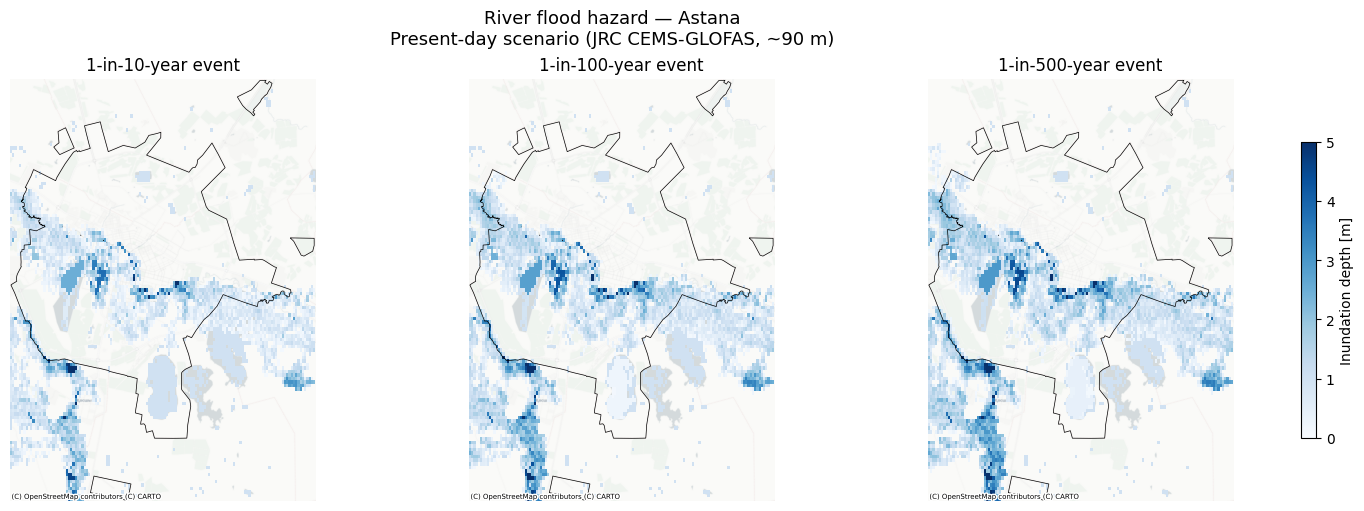

In [ ]:
max_inundation = 5  
rps_plot       = [10, 100, 500]

fig, axs = plt.subplots(
    1, 3,
    figsize=(15, 5),
    constrained_layout=True,
    sharex=True, sharey=True,
)

for ii, rp in enumerate(rps_plot):
    step    = max(1, int(500 / 90))
    da_plot = floodmaps[f"RP{rp}"].isel(
        x=slice(None, None, step),
        y=slice(None, None, step),
    )
    bs = da_plot.plot(
        ax=axs[ii],
        cmap="Blues",
        vmin=0, vmax=max_inundation,
        add_colorbar=False,
    )
    region_gdf.boundary.plot(ax=axs[ii], color="black", linewidth=0.5)
    axs[ii].set_title(f"1-in-{rp}-year event")
    ctx.add_basemap(
        ax=axs[ii],
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        attribution_size=5,
    )
    axs[ii].set_axis_off()

fig.colorbar(
    bs, ax=axs.ravel().tolist(),
    orientation="vertical",
    label="Inundation depth [m]",
    shrink=0.7,
)
fig.suptitle(
    f"River flood hazard — {region_name}\n"
    "Present-day scenario (JRC CEMS-GLOFAS, ~90 m)",
    fontsize=13,
)
out_fig = plot_dir / f"Floodmap_overview_GLOFAS_PresentScenario_{region_name}.png"
fig.savefig(out_fig, dpi=150, bbox_inches="tight")
print(f"Saved: {out_fig.name}")
plt.show()

### Step 5 — Save present-day flood hazard data

In [ ]:
nc_out = data_dir / f"floodmaps_GLOFAS_PresentScenario_{region_name}.nc"
floodmaps.to_netcdf(nc_out)
print(f"Saved: {nc_out.name}")

for rp in return_periods:
    tif_out = data_dir / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"
    da = floodmaps[f"RP{rp}"].squeeze()
    da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
    da.rio.write_crs("EPSG:4326", inplace=True)
    da.rio.to_raster(tif_out)
    print(f"Saved: {tif_out.name}")

Saved: floodmaps_GLOFAS_PresentScenario_Astana.nc
Saved: floodmap_GLOFAS_PresentScenario_Astana_RP10.tif
Saved: floodmap_GLOFAS_PresentScenario_Astana_RP50.tif
Saved: floodmap_GLOFAS_PresentScenario_Astana_RP100.tif
Saved: floodmap_GLOFAS_PresentScenario_Astana_RP200.tif
Saved: floodmap_GLOFAS_PresentScenario_Astana_RP500.tif


---
## Part 2 — Future flood hazard under climate scenarios: Aqueduct Floods

This section uses the WRI Aqueduct Floods dataset, which is already global
and is used **unchanged** from the original CLIMAAX workflow — no dataset
substitution is required here.

| Parameter | Value |
|---|---|
| Scenarios | RCP4.5/SSP2, RCP8.5/SSP3 |
| Time horizons | 1980 (baseline), 2030, 2050, 2080 |
| Models | NorESM1-M, GFDL-ESM2M, HadGEM2-ES, IPSL-CM5A-LR, MIROC-ESM-CHEM |
| Resolution | ~1 km (30 arc-seconds) |
| Return period used | 250 years (as in original CLIMAAX workflow) |

**Scenario note:** Aqueduct uses RCP4.5 and RCP8.5.  The rest of this
Kazakhstan repository uses SSP1-2.6 and SSP3-7.0 (ISIMIP3b).  These are
not identical forcings, but are broadly comparable in magnitude.  This
mismatch is inherent to using Aqueduct for future flood scenarios and is
documented here for transparency.

**Filename format:**
`inunriver_{scenario}_{model_padded14}_{year}_rp{rp:05d}.tif`
where `model_padded14` is the model name left-padded with zeros to 14
characters (e.g. `NorESM1-M` → `00000NorESM1-M`).

In [ ]:
return_period_aq = 250   

MODELS    = ["NorESM1-M", "GFDL-ESM2M", "HadGEM2-ES", "IPSL-CM5A-LR", "MIROC-ESM-CHEM"]
YEARS     = [2030, 2050, 2080]
SCENARIOS = ["rcp4p5", "rcp8p5"]
AQ_BASE   = "http://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2"

### Step 6 — Load Aqueduct baseline (ca. 1980)

In [ ]:
aq_fname_base = (
    f"inunriver_historical_000000000WATCH_1980_rp{return_period_aq:05d}.tif"
)
aq_path_global = general_data_folder / aq_fname_base
aq_out_base    = data_dir_aqueduct / aq_fname_base.replace(".tif", f"_{region_name}.nc")

if not aq_out_base.exists():
    if not aq_path_global.exists():
        print(f"Downloading baseline: {aq_fname_base}")
        pooch.retrieve(
            url=f"{AQ_BASE}/{aq_fname_base}",
            known_hash=None,
            path=general_data_folder,
            fname=aq_fname_base,
        )
    else:
        print(f"Cached global: {aq_fname_base}")

    with rxr.open_rasterio(aq_path_global) as ds:
        aq_base = ds.rio.clip_box(*bbox, crs=ds.rio.crs)
        aq_base = aq_base.where(aq_base > 0)
        aq_base.name = "inun"
        aq_base = (
            aq_base
            .assign_coords(year=1980).expand_dims("year")
            .assign_coords(scenario="baseline").expand_dims("scenario")
            .to_dataset()
        )
        aq_base.to_netcdf(aq_out_base)

    if aq_path_global.exists():
        aq_path_global.unlink()
    print(f"Saved clipped baseline: {aq_out_base.name}")
else:
    aq_base = xr.open_dataset(aq_out_base)
    print(f"Cached: {aq_out_base.name}")

SHA256 hash of downloaded file: 6352ecd105747f114313b47db86944690740ebb005bd6f72fb5d8e1a3adc2873
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Saved clipped baseline: inunriver_historical_000000000WATCH_1980_rp00250_Astana.nc


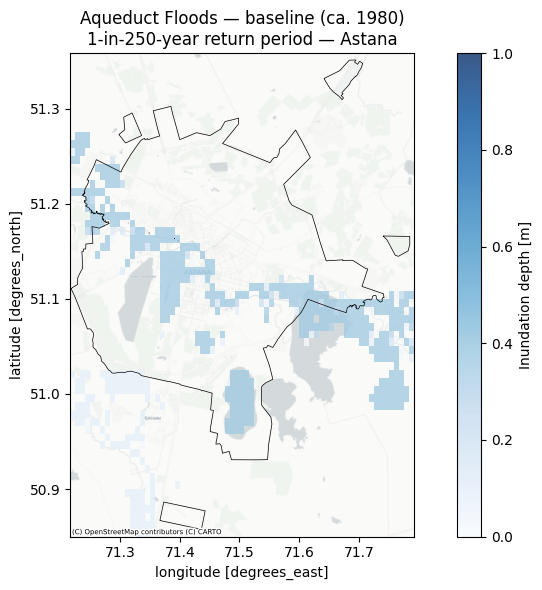

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
vmax_base = float(np.ceil(float(aq_base["inun"].max())))
aq_base["inun"].plot(
    ax=ax,
    cmap="Blues",
    alpha=0.8,
    vmin=0, vmax=max(vmax_base, 0.1),
    cbar_kwargs={"label": "Inundation depth [m]"},
)
region_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
ctx.add_basemap(
    ax=ax, crs="EPSG:4326",
    source=ctx.providers.CartoDB.Positron,
    attribution_size=5,
)
ax.set_title(
    f"Aqueduct Floods — baseline (ca. 1980)\n"
    f"1-in-{return_period_aq}-year return period — {region_name}"
)
plt.tight_layout()
fig.savefig(
    plot_dir / f"Floodmap_Aqueduct_baseline_{region_name}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

### Step 7 — Download Aqueduct future scenario tiles (skip if cached)

In [ ]:
for scenario in SCENARIOS:
    for year in YEARS:
        for model in MODELS:
            model_padded = model.rjust(14, "0")
            fname   = f"inunriver_{scenario}_{model_padded}_{year}_rp{return_period_aq:05d}.tif"
            g_path  = general_data_folder / fname
            out_nc  = data_dir_aqueduct / fname.replace(".tif", f"_{region_name}.nc")

            if out_nc.exists():
                print(f"Cached: {out_nc.name}")
                continue

            if not g_path.exists():
                print(f"Downloading: {fname}")
                pooch.retrieve(
                    url=f"{AQ_BASE}/{fname}",
                    known_hash=None,
                    path=general_data_folder,
                    fname=fname,
                )

            with rxr.open_rasterio(g_path) as ds:
                aq_local = ds.rio.clip_box(*bbox, crs=ds.rio.crs)
                aq_local.load()
                aq_local = aq_local.where(aq_local > 0)
                aq_local.name = "inun"
                aq_local = (
                    aq_local
                    .assign_coords(year=year).expand_dims("year")
                    .assign_coords(scenario=scenario).expand_dims("scenario")
                    .assign_coords(model=model).expand_dims("model")
                    .to_dataset()
                )
                aq_local.to_netcdf(out_nc)
                print(f"Saved: {out_nc.name}")

            if g_path.exists():
                g_path.unlink()

Downloading: inunriver_rcp4p5_00000NorESM1-M_2030_rp00250.tif


SHA256 hash of downloaded file: 3b51f0e0efe73f6cfc7be72f0137e2a0847d94dc4821840b749d5432f587d875
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Saved: inunriver_rcp4p5_00000NorESM1-M_2030_rp00250_Astana.nc
Downloading: inunriver_rcp4p5_0000GFDL-ESM2M_2030_rp00250.tif


SHA256 hash of downloaded file: 2e3f872064fd212b5bee6774c9709b1d7d8c1593a92d72c9c9f273e72d7bdd45
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Saved: inunriver_rcp4p5_0000GFDL-ESM2M_2030_rp00250_Astana.nc
Downloading: inunriver_rcp4p5_0000HadGEM2-ES_2030_rp00250.tif


...

Saved: inunriver_rcp8p5_0000HadGEM2-ES_2080_rp00250_Astana.nc
Downloading: inunriver_rcp8p5_00IPSL-CM5A-LR_2080_rp00250.tif


SHA256 hash of downloaded file: e9447d59a3e6f0581549091089636a9ac8da0f6081aad91217c8347b4568e0f6
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Saved: inunriver_rcp8p5_00IPSL-CM5A-LR_2080_rp00250_Astana.nc
Downloading: inunriver_rcp8p5_MIROC-ESM-CHEM_2080_rp00250.tif


SHA256 hash of downloaded file: d07477c07b3c5af921f4a411258a5be590199c2271edb45b2243aac812519def
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Saved: inunriver_rcp8p5_MIROC-ESM-CHEM_2080_rp00250_Astana.nc


### Step 8 — Compute multi-model mean and save combined dataset

In [19]:
from collections import defaultdict

groups = defaultdict(list)

for sc in SCENARIOS:
    for y in YEARS:
        for m in MODELS:
            nc = (
                data_dir_aqueduct
                / f"inunriver_{sc}_{m.rjust(14,'0')}_{y}_rp{return_period_aq:05d}_{region_name}.nc"
            )
            da = xr.open_dataset(nc)["inun"].squeeze()
            groups[(sc, y)].append(da)
            print(f"  Loaded: {nc.name}")

scenario_arrays = []
for sc in SCENARIOS:
    year_arrays = []
    for y in YEARS:
        da_list = groups[(sc, y)]
        stacked = xr.concat(da_list, dim="model").assign_coords(model=MODELS)
        mean_da = stacked.mean(dim="model")
        mean_da = mean_da.assign_coords(year=y).expand_dims("year")
        year_arrays.append(mean_da)
    sc_da = xr.concat(year_arrays, dim="year")
    sc_da = sc_da.assign_coords(scenario=sc).expand_dims("scenario")
    scenario_arrays.append(sc_da)

aq_mean      = xr.concat(scenario_arrays, dim="scenario").to_dataset(name="inun")
aq_mean_path = (
    data_dir_aqueduct
    / f"inunriver_AllScenarios_ModelMean_AllYears_rp{return_period_aq:05d}_{region_name}.nc"
)
aq_mean.to_netcdf(aq_mean_path)
print(f"\nSaved model-mean dataset: {aq_mean_path.name}")
print(aq_mean)

  Loaded: inunriver_rcp4p5_00000NorESM1-M_2030_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000GFDL-ESM2M_2030_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000HadGEM2-ES_2030_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_00IPSL-CM5A-LR_2030_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_MIROC-ESM-CHEM_2030_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_00000NorESM1-M_2050_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000HadGEM2-ES_2050_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_00IPSL-CM5A-LR_2050_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_00000NorESM1-M_2080_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000GFDL-ESM2M_2080_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_0000HadGEM2-ES_2080_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_00IPSL-CM5A-LR_2080_rp00250_Astana.nc
  Loaded: inunriver_rcp4p5_MIROC-ESM-CHEM_2080_rp00250_Astana.nc
  Loaded: inunriver_rcp8p

### Step 9 — Compare flood maps under future climate scenarios

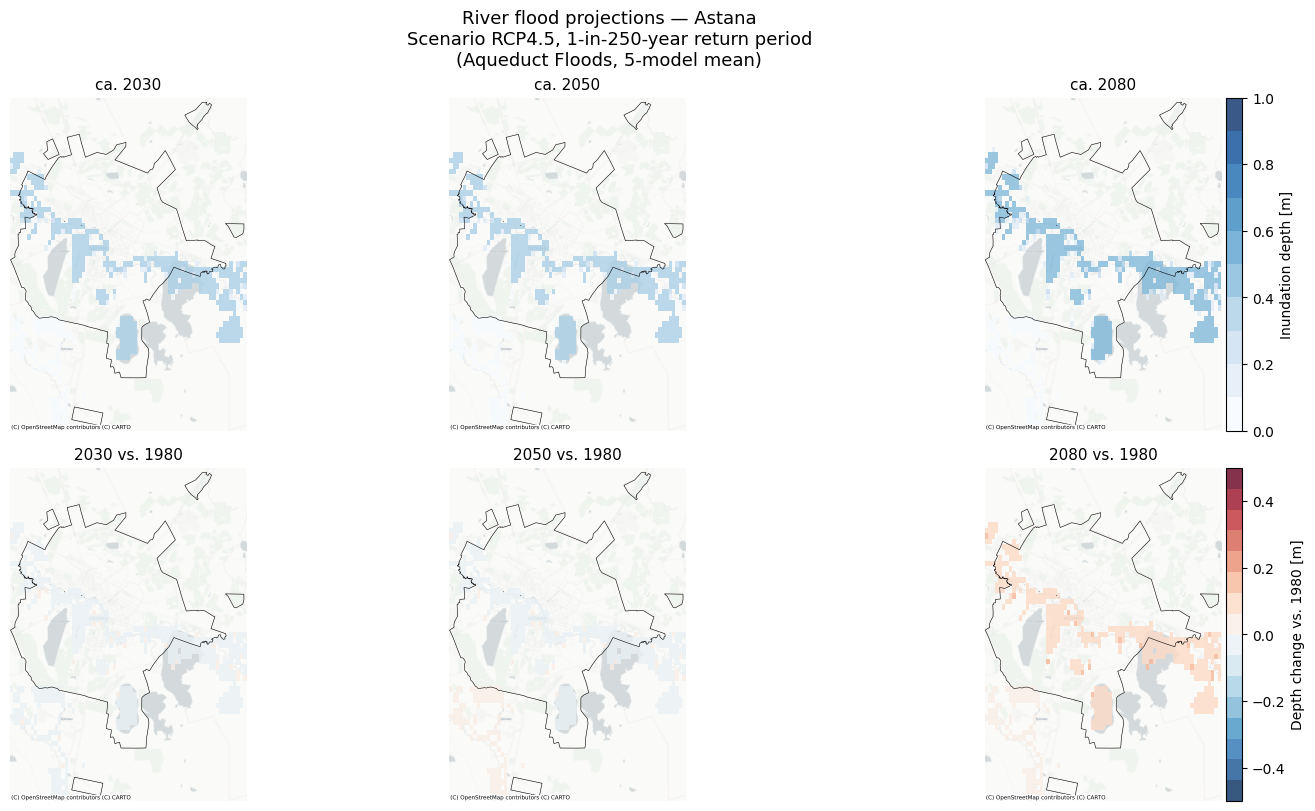

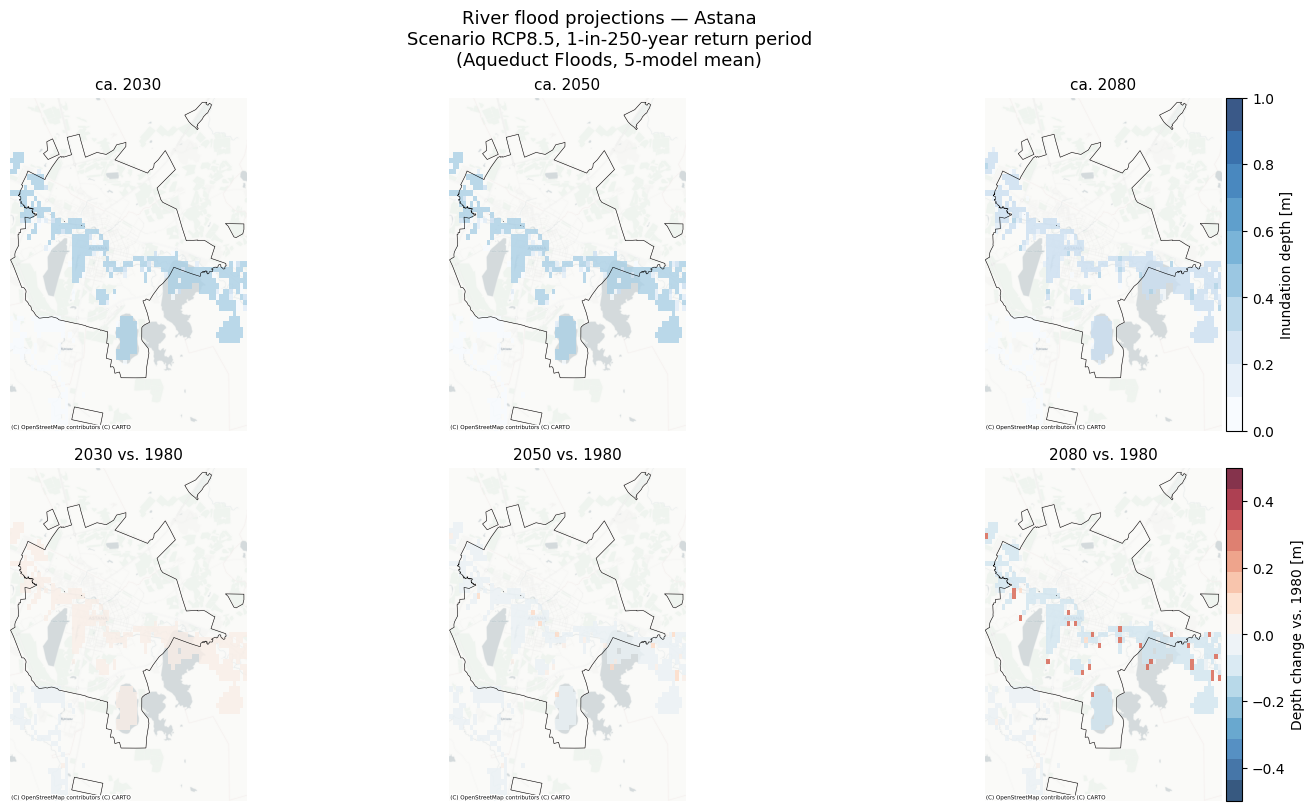

In [ ]:
cmap_flood = plt.get_cmap("Blues", 10)
cmap_diff  = plt.get_cmap("RdBu_r", 16)

aq_base = xr.open_dataset(aq_out_base)
aq_all  = xr.open_dataset(aq_mean_path)

vmax_abs  = float(np.ceil(float(aq_all["inun"].max())))
lims_diff = [-0.5, 0.5]  

for scenario in SCENARIOS:
    scen_label = scenario.replace("rcp4p5", "RCP4.5").replace("rcp8p5", "RCP8.5")

    fig, axs = plt.subplots(
        2, 3,
        figsize=(14, 8),
        sharex=True, sharey=True,
        constrained_layout=True,
    )
    fig.suptitle(
        f"River flood projections — {region_name}\n"
        f"Scenario {scen_label}, 1-in-{return_period_aq}-year return period\n"
        "(Aqueduct Floods, 5-model mean)",
        fontsize=13,
    )

    for jj, year in enumerate(YEARS):
        da_scen = aq_all["inun"].sel(year=year, scenario=scenario).squeeze()
        da_diff = (da_scen - aq_base["inun"].squeeze()).squeeze()
        last    = jj == len(YEARS) - 1

        da_scen.plot(
            ax=axs[0, jj], cmap=cmap_flood, alpha=0.8,
            vmin=0, vmax=max(vmax_abs, 0.1),
            add_colorbar=last,
            cbar_kwargs={"label": "Inundation depth [m]",
                         "pad": 0.01, "aspect": 20} if last else {},
        )
        region_gdf.boundary.plot(ax=axs[0, jj], color="black", linewidth=0.4)
        ctx.add_basemap(
            axs[0, jj], crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            attribution_size=4,
        )
        axs[0, jj].set_title(f"ca. {year}", fontsize=11)
        axs[0, jj].set_axis_off()

        da_diff.plot(
            ax=axs[1, jj], cmap=cmap_diff, alpha=0.8,
            vmin=lims_diff[0], vmax=lims_diff[1],
            add_colorbar=last,
            cbar_kwargs={"label": "Depth change vs. 1980 [m]",
                         "pad": 0.01, "aspect": 20} if last else {},
        )
        region_gdf.boundary.plot(ax=axs[1, jj], color="black", linewidth=0.4)
        ctx.add_basemap(
            axs[1, jj], crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            attribution_size=4,
        )
        axs[1, jj].set_title(f"{year} vs. 1980", fontsize=11)
        axs[1, jj].set_axis_off()

    scen_safe = scen_label.replace(".", "")
    fig.savefig(
        plot_dir / f"Floodmaps_Aqueduct_{region_name}_{scen_safe}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

---
## Conclusions

This hazard workflow demonstrated:

- Retrieving JRC CEMS-GLOFAS global flood maps for Kazakhstan by automatically
  identifying the relevant 10°×10° tiles from the published tile index,
  downloading them, mosaicking, and clipping to the region of interest.
- Interpreting river flood maps for different return periods under the
  present-day scenario (CEMS-GLOFAS, ~90 m resolution).
- Downloading and comparing WRI Aqueduct Floods coarse-resolution (~1 km)
  flood maps under RCP4.5 and RCP8.5 climate scenarios (2030, 2050, 2080)
  relative to the 1980 baseline.

**Kazakhstan-specific notes:**
- The Irtysh, Syr Darya, Ural, Ili, and Tobol river systems are the primary
  flood-prone networks and should show the most prominent flood extents in
  GLOFAS maps.
- The GLOFAS dataset covers only river basins > 150 km²; smaller watercourses
  in mountainous areas (e.g. Tian Shan foothills) will not appear.
- The Aqueduct dataset carries substantial uncertainty at national scale.
  Results should be treated as qualitative indicators of climate change
  direction, not precise local flood depth estimates.
- The Aqueduct RCP4.5/RCP8.5 scenarios differ from the SSP1-2.6/SSP3-7.0
  forcing used in other Kazakhstan workflows (droughts, heatwaves).  This
  mismatch is inherent to the dataset and is documented for transparency.
- These flood hazard maps are the intended input for the river flood
  risk assessment workflow (exposure × vulnerability).